# Speed Tests

In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import functions_regular as fnr
import functions_subtrees as fns
import functions_regular_wc as fnr_wc
import functions_subtrees_wc as fns_wc
import functions_subtrees_wcs as fns_wcs
import matplotlib.pyplot as plt
import importlib
import numpy.lib.recfunctions as rfn
import cProfile as cp
import random as rnd
import itertools as it
import collections
import math
import time
import pickle
import json
importlib.reload(fnr)
importlib.reload(fns)
importlib.reload(fnr_wc)
importlib.reload(fns_wc)
importlib.reload(fns_wcs)

<module 'functions_subtrees_wcs' from '/Users/mbpr/Desktop/internships/CU Boulder Summer 2019/Motif discovery/motif-discovery/src/functions_subtrees_wcs.py'>

# CommunityFitNet_updated

### read

In [2]:
f = open('test_data/CommunityFitNet_updated.pickle', 'rb')
data = pickle.load(f)

In [3]:
data_edgelists = data['edges_id']
data.columns

Index(['network_index', 'network_name', 'title', 'description',
       'networkDomain', 'subDomain', 'citation', 'sourceUrl', 'hostedBy',
       'graphProperties', 'nodeType', 'edgeType', 'nodes_id', 'edges_id',
       'number_nodes', 'number_edges', 'ave_degree', 'labels_Q', 'labels_Q_MR',
       'labels_Q_MP', 'labels_Q_GMP', 'labels_B_NR_SBM', 'labels_B_NR_DCSBM',
       'labels_B_HKK_SBM', 'labels_cICL_HKK_SBM', 'labels_Infomap',
       'labels_MDL_SBM', 'labels_MDL_DCSBM', 'labels_S_NB', 'labels_S_cBHm',
       'labels_S_cBHa', 'labels_AMOS', 'labels_AMOS_reliablity',
       'labels_LRT_WB_DCSBM', 'Q_score', 'Q_MR_score', 'Q_MP_score',
       'Q_GMP_score', 'B_NR_SBM_score', 'B_NR_DCSBM_score', 'B_HKK_SBM_score',
       'cICL_HKK_SBM_score', 'Infomap_score', 'MDL_SBM_score',
       'MDL_DCSBM_score', 'S_NB_score', 'S_cBHm_score', 'S_cBHa_score',
       'AMOS_score', 'LRT_WB_DCSBM_score'],
      dtype='object')

### browse networks

In [56]:
from operator import itemgetter, attrgetter

networks = [(data['network_index'][i], 
              data['number_nodes'][i],
              data['title'][i]) for i in range(len(data)) if data['graphProperties'][i][0] == 'U']

# sored by size
sorted(networks, key = itemgetter(1))


[(9, 5, 'Binary interactomes (various species; 2012)'),
 (10, 5, 'Binary interactomes (various species; 2012)'),
 (12, 8, 'Binary interactomes (various species; 2012)'),
 (45, 9, 'Davidson plant-ant web'),
 (13, 13, 'Binary interactomes (various species; 2012)'),
 (416, 15, 'AMiner citation network (2009)'),
 (417, 15, 'AMiner citation network (2009)'),
 (128, 18, 'Malaria var DBLa HVR networks'),
 (421, 19, 'AMiner citation network (2009)'),
 (23, 22, 'Binary interactomes (various species; 2012)'),
 (24, 22, 'Binary interactomes (various species; 2012)'),
 (138, 22, 'Mosquin & Martin plant-pollinator web'),
 (365, 22, 'Olesen plant-pollinator web'),
 (394, 23, 'Vazquez & Simberloff plant-pollinator webs'),
 (373, 24, 'Poulin seed-disperser web'),
 (14, 26, 'Binary interactomes (various species; 2012)'),
 (366, 27, 'Olesen plant-pollinator web'),
 (28, 28, 'Binary interactomes (various species; 2012)'),
 (380, 28, 'Smallwood Reservoir host-parasite web'),
 (52, 29, 'Fonseca & Ganade pl

### view details

In [41]:
data['sourceUrl'][375]

'http://www.ncbi.nlm.nih.gov/pmc/articles/PMC1561585/'

### plot network

In [ ]:
#arguments: networkIndex, nodeSize, withLabels, figSize
plotNetwork(36, 10, False, 18)

In [ ]:
plotNetwork(258, 10, False, 18)

### find max peripheral hub degree

In [712]:
networkGraph = nx.Graph()
edges = data_edgelists.iloc[26]
networkGraph.add_edges_from(edges)

fns.onionDecompose(networkGraph)

maxBushLength = 0

for node in networkGraph:
    if (networkGraph.nodes[node]['is_root']):
        
        neighborhood = networkGraph[node]
        bushLength = len([i for i in neighborhood if networkGraph.nodes[i]['coreness'] == 1])
        
        if (bushLength > maxBushLength):
            maxBushLength = bushLength
            
            
maxBushLength

14

### plot query graph

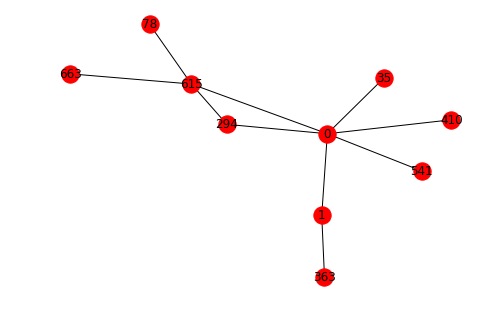

In [741]:
queryString = '[[0,1], [0,35], [0,294], [0,410], [0,541], [0,615], [1,363], [294,615], [615,78], [615,663]]'
queryGraph = parseStringToGraph(queryString)
nx.draw(queryGraph, with_labels=True)

### test early abort by coreness

In [68]:
networkIndex = 372

# without early abort by coreness
networkGraph = nx.Graph()
edges = data_edgelists.iloc[networkIndex]
networkGraph.add_edges_from(edges)

queryString = '[[0,1], [0,2], [0,3], [0,4], [0,5], [0,6], [0,7], [1,2], [1,3], [1,4], [1,5], [1,6], [1,7], [2,3], [2,4], [2,5], [2,6], [2,7], [3,4], [3,5], [3,6], [3,7], [4,5], [4,6], [4,7], [5,6], [5,7], [6,7]]'
queryGraph = parseStringToGraph(queryString)

start_time_fnr = time.time()
out_fnr = fnr_wc.findSubgraphInstances(queryGraph, networkGraph, True)
delta_fnr = time.time() - start_time_fnr


# with early abort by coreness
networkGraph = nx.Graph()
edges = data_edgelists.iloc[networkIndex]
networkGraph.add_edges_from(edges)
fns.onionDecompose(networkGraph)

queryGraph = parseStringToGraph(queryString)
fns.onionDecompose(queryGraph)

start_time_fnr_wc = time.time()
out_fnr_wc = fnr_wc.findSubgraphInstances(queryGraph, networkGraph, True)
delta_fnr_wc = time.time() - start_time_fnr_wc

print(delta_fnr, delta_fnr_wc)


114.36780405044556 99.60093402862549


In [ ]:
print(out_fnr, out_fnr_wc)
queryGraph.nodes[0]['coreness']

### view k-core spectrum

In [739]:
networkGraph = nx.Graph()
edges = data_edgelists.iloc[117]
networkGraph.add_edges_from(edges)
traversal = fns.onionDecompose(networkGraph)

print([(traversal[i], networkGraph.nodes[traversal[i]]['coreness']) for i in range(len(networkGraph))])

oneShellSize = len([networkGraph.nodes[i]['coreness'] for i in networkGraph.nodes() if networkGraph.nodes[i]['coreness']==1])

print('1-shell size', oneShellSize)
print('2-core size',len(networkGraph)-oneShellSize)
print('network size', len(networkGraph))

[(21, 1), (22, 1), (53, 1), (78, 1), (2, 1), (3, 1), (19, 1), (27, 1), (37, 1), (54, 1), (69, 1), (76, 1), (203, 1), (474, 1), (509, 1), (533, 1), (612, 1), (712, 1), (208, 1), (234, 1), (261, 1), (380, 1), (384, 1), (759, 1), (80, 1), (175, 1), (196, 1), (198, 1), (205, 1), (273, 1), (326, 1), (383, 1), (422, 1), (441, 1), (445, 1), (447, 1), (452, 1), (617, 1), (620, 1), (683, 1), (692, 1), (17, 1), (8, 1), (131, 1), (137, 1), (141, 1), (146, 1), (149, 1), (153, 1), (154, 1), (160, 1), (161, 1), (162, 1), (163, 1), (164, 1), (165, 1), (167, 1), (168, 1), (169, 1), (184, 1), (185, 1), (204, 1), (212, 1), (216, 1), (218, 1), (220, 1), (231, 1), (232, 1), (246, 1), (253, 1), (258, 1), (275, 1), (276, 1), (277, 1), (296, 1), (297, 1), (314, 1), (319, 1), (322, 1), (324, 1), (327, 1), (331, 1), (342, 1), (346, 1), (348, 1), (349, 1), (350, 1), (351, 1), (352, 1), (353, 1), (355, 1), (356, 1), (357, 1), (359, 1), (360, 1), (363, 1), (364, 1), (365, 1), (370, 1), (374, 1), (375, 1), (376, 1

### find all undirected networks in dataset

In [ ]:
undirected_networks = ''

for i in list(data['network_index']):
    if (data['graphProperties'][i][0] == 'U'):
        undirected_networks += str(i) + ' '
        
undirected_networks

### compare runtimes on a selection of networks

In [ ]:
# network data, selections
data_edgelists = data['edges_id']
indices_smallSelection = [26] #[513, 372, 254, 33, 471, 4, 26, 503]

querySize = 5

inputFile = 'test_data/allgraphs' + str(querySize) + 'indexed.txt'
f = open(inputFile, 'r')
queryGraphsData = f.readlines()

results = {}

for networkKey, networkIndex in enumerate(indices_smallSelection):
    
    # create nx.graph and string encoding of network
    networkGraph = nx.Graph()
    edges = data_edgelists.iloc[networkIndex]
    networkGraph.add_edges_from(edges)
    networkString = graphToString(networkGraph)
    
    runtimes = {}
    sig = False

    # get test motifs
    for key, val in enumerate(queryGraphsData):
        
        spaceIndex = val.find(' ')
        queryKey = val[:spaceIndex]
        queryString = val[spaceIndex+1:].rstrip()
        queryGraph = parseStringToGraph(queryString)
        networkGraph = parseStringToGraph(networkString)
        
        print('network:', networkIndex, 'query:', queryString)
        
        # run fnr, fns
        start_time_fns = time.time()
        out_fns = fns_wcs.findSubgraphInstances(queryString, networkString)
        delta_fns = time.time() - start_time_fns
        
        start_time_fnr = time.time()
        out_fnr = fnr_wc.findSubgraphInstances(queryGraph, networkGraph, True)
        delta_fnr = time.time() - start_time_fnr
        
        if (out_fnr != out_fns):
            sig = True
            print('error! outputs unequal at query', queryString, 'and network', networkIndex)
            break
        
        # store index, delta, queryGraph, 2-core size in dict
        runtimes[queryKey] = {'runtime_fnr': delta_fnr,
                              'runtime_fns': delta_fns}
        
        currentStep = (networkKey)*len(queryGraphsData) + key
        totalSteps = len(indices_smallSelection) * len(queryGraphsData)
        
        print('progress: ', int(currentStep*100/totalSteps), '%')
        
    if (sig):
        break
    
    results[networkIndex] = runtimes

print(results)

In [504]:
with open('test_data/speed_tests/small_sample/results_allgraphs5_on_8sample.json', 'w') as fp:
    json.dump(results, fp)

### calculate total runtime

In [505]:
totalTime = 0

for i in indices_smallSelection:
    for j in range(21):
        totalTime = totalTime + results[i][str(j)]['runtime_fnr'] + results[i][str(j)]['runtime_fns']
        
totalTime/60

178.79789437055587

In [69]:
indices_smallSelection = [513, 372, 254, 33, 471, 4, 26, 503]

### sizes 3 and 4

In [70]:
data_ = {}
runtimes = {}
obj = {}

for querySize in range(3, 5):
    with open('test_data/speed_tests/8sample/results_allgraphs'+str(querySize)+'_on_8sample.json', 'r') as fp:
        data_[querySize] = fp.read()
        obj[querySize] = json.loads(data_[querySize])

howManyQuerys = [2, 6]

for networkIndex in indices_smallSelection:
    runtimes[networkIndex] = {}
    
    for querySize in range(3, 5):
        
        totalRuntime_fnr = 0
        totalRuntime_fns = 0
        
        for i in range(howManyQuerys[querySize-3]):
            if (obj[querySize][str(networkIndex)][str(i)] != 'error'):
                totalRuntime_fnr = totalRuntime_fnr + obj[querySize][str(networkIndex)][str(i)]['runtime_fnr']
                totalRuntime_fns = totalRuntime_fns + obj[querySize][str(networkIndex)][str(i)]['runtime_fns']

        runtimes[networkIndex][querySize] = {'total_fnr': totalRuntime_fnr,
                                             'total_fns': totalRuntime_fns}


### sizes 5 through 8

In [71]:
# from first file: take fnr
# from second file: take fns
# put them in runtimes

data_fnr = {}
data_fns = {}
obj_fnr = {}
obj_fns = {}

for querySize in range(5, 9):
    # first file
    with open('test_data/speed_tests/8sample/results_allgraphs'+str(querySize)+'_on_8sample_fnr&fns.json', 'r') as fp:
        data_fnr[querySize] = fp.read()
        obj_fnr[querySize] = json.loads(data_fnr[querySize])

    # second file
    with open('test_data/speed_tests/8sample/results_allgraphs'+str(querySize)+'_on_8sample_wcs.json', 'r') as fr:
        data_fns[querySize] = fr.read()
        obj_fns[querySize] = json.loads(data_fns[querySize])

howManyQuerys = [21, 112, 853, 11117]

for networkIndex in indices_smallSelection:
    for querySize in range(5, 9):
        
        totalRuntime_fnr = 0
        totalRuntime_fns = 0
        
        for i in range(howManyQuerys[querySize-5]):
            
            if (str(networkIndex) in obj_fnr[querySize]):
                if (obj_fnr[querySize][str(networkIndex)][str(i)] != 'error' and 'runtime_fnr' in obj_fnr[querySize][str(networkIndex)][str(i)]):
                    totalRuntime_fnr = totalRuntime_fnr + obj_fnr[querySize][str(networkIndex)][str(i)]['runtime_fnr']
            
            if (str(networkIndex) in obj_fns[querySize]):
                if (obj_fns[querySize][str(networkIndex)][str(i)] != 'error' and 'runtime_fns' in obj_fns[querySize][str(networkIndex)][str(i)]):
                    totalRuntime_fns = totalRuntime_fns + obj_fns[querySize][str(networkIndex)][str(i)]['runtime_fns']

        if (totalRuntime_fnr == 0):
            totalRuntime_fnr = None

        if (totalRuntime_fns == 0):
            totalRuntime_fns = None
            
        runtimes[networkIndex][querySize] = {'total_fnr': totalRuntime_fnr,
                                             'total_fns': totalRuntime_fns}

In [163]:
np.argmax([obj_fnr[5]['503'][str(i)]['runtime_fnr'] for i in range(21)])

5

In [72]:
runtimes

{513: {3: {'total_fnr': 1.2768888473510742, 'total_fns': 4.803285121917725},
  4: {'total_fnr': 7.793758869171143, 'total_fns': 12.92606234550476},
  5: {'total_fnr': 38.47878646850586, 'total_fns': 61.85220265388489},
  6: {'total_fnr': 272.589453458786, 'total_fns': 336.8291845321655},
  7: {'total_fnr': 1905.7834084033966, 'total_fns': 2291.918925046921},
  8: {'total_fnr': 22049.12962961197, 'total_fns': 24502.081691026688}},
 372: {3: {'total_fnr': 3.4057679176330566, 'total_fns': 5.806246995925903},
  4: {'total_fnr': 57.95198607444763, 'total_fns': 67.53426790237427},
  5: {'total_fnr': 790.1029720306396, 'total_fns': 953.317705154419},
  6: {'total_fnr': 10815.674908638, 'total_fns': 12256.857212305069},
  7: {'total_fnr': None, 'total_fns': None},
  8: {'total_fnr': None, 'total_fns': None}},
 254: {3: {'total_fnr': 1.3231987953186035, 'total_fns': 0.8321044445037842},
  4: {'total_fnr': 12.6171875, 'total_fns': 2.764768600463867},
  5: {'total_fnr': 91.22603631019592, 'total_

### plot networks and runtime comparison

/Users/mbpr/anaconda3/lib/python3.7/site-packages/networkx/drawing/nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):
/Users/mbpr/anaconda3/lib/python3.7/site-packages/networkx/drawing/nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):
/Users/mbpr/anaconda3/lib/python3.7/site-packages/networkx/drawing/nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):
/Users/mbpr/anaconda3/lib/python3.7/site-packages/networkx/drawing/nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):
/Users/mbpr/anaconda3/lib/python3.7/site-packages/networkx/drawing/nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):
/Users/mbpr/anaconda3/lib/python3.7/site-packages/networkx/drawing/nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbe

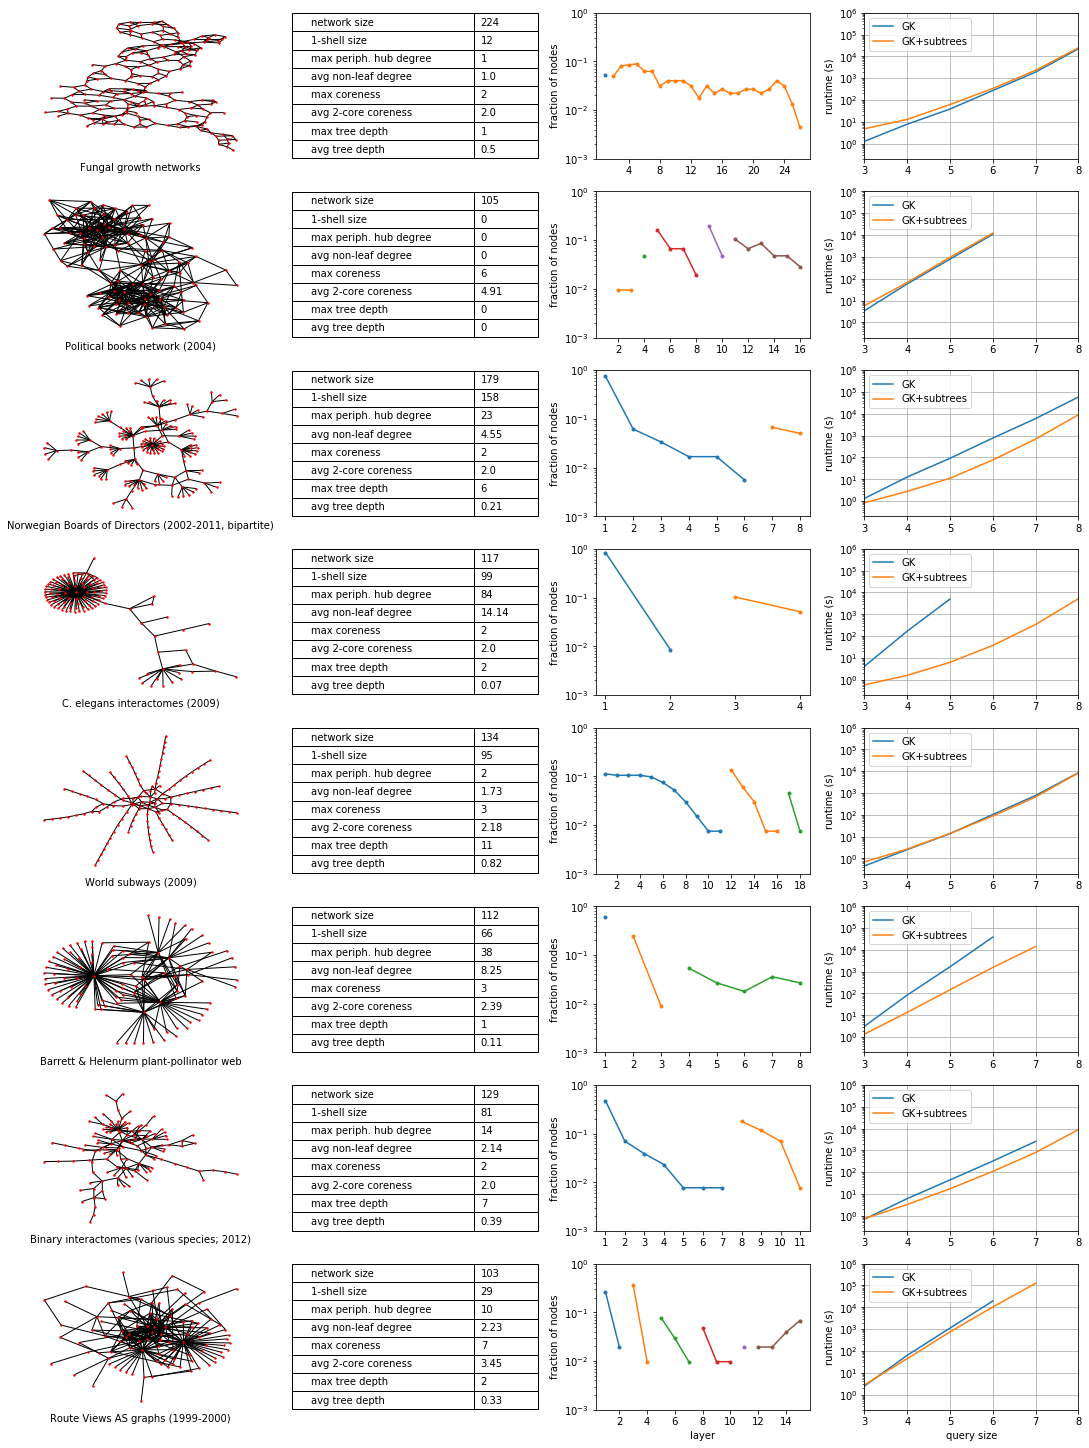

In [53]:
from matplotlib.ticker import MaxNLocator

sample = indices_smallSelection
sampleSize = len(sample)

fig1, f1_axes = plt.subplots(ncols=4, nrows=sampleSize, constrained_layout=True)

for networkKey, networkIndex in enumerate(sample):
    edges = data_edgelists.iloc[networkIndex]
    networkGraph = nx.Graph()
    networkGraph.add_edges_from(edges)
    traversal = fns_wc.onionDecompose(networkGraph)
    
    # 1. get onion spectrum, fraction of nodes of layer x versus x, for each core separately
    onionLayers = {}
    coreness = 1
    layer = 1
    onionLayers[coreness] = {}
    onionLayers[coreness][layer] = []
    
    for i in range(len(networkGraph)):
        node = traversal[i]
        
        if (coreness != networkGraph.nodes[node]['coreness']):
            coreness = networkGraph.nodes[node]['coreness']
            onionLayers[coreness] = {}
        
        if (layer != networkGraph.nodes[node]['onion_layer']):
            layer = networkGraph.nodes[node]['onion_layer']
            onionLayers[coreness][layer] = [node]
        
        else :
            onionLayers[coreness][layer].append(node)
    
    ax1 = f1_axes[networkKey,0]
    ax2 = f1_axes[networkKey,1]
    ax3 = f1_axes[networkKey,2]
    ax4 = f1_axes[networkKey,3]
    
    
    # network
    pos = nx.drawing.kamada_kawai_layout(networkGraph, scale=1)
    nodes = nx.draw_networkx_nodes(networkGraph, pos=pos, node_size = 2, ax = ax1)
    edges = nx.draw_networkx_edges(networkGraph, pos=pos, ax = ax1)
    
    ax1.set_xticks([])
    ax1.set_yticks([])
    ax1.set_xlabel(str(data['title'][networkIndex]))
#     ax1.set_aspect('equal')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['bottom'].set_visible(False)
    ax1.spines['left'].set_visible(False)
    
    
    # network statistics
    oneShellSize = len([i for i in networkGraph if networkGraph.nodes[i]['coreness'] == 1])

    maxCoreness = max(onionLayers.keys())
    
    twoCore = [i for i in networkGraph if networkGraph.nodes[i]['coreness'] >= 2]
    avgCorenessTwoCore = sum([networkGraph.nodes[i]['coreness'] for i in twoCore])/len(twoCore)
    
    maxPeripheralHubDegree = 0
    avgOneShellDegree = 0
    rootCount = 0
    avgTreeDepth = 0
    nonLeafSize = 0
    
    for node in networkGraph:
        if (networkGraph.nodes[node]['is_root'] or networkGraph.nodes[node]['coreness'] == 1):
            rootCount = rootCount + 1

            neighborhood = networkGraph[node]
            peripheralNeighborhood = [i for i in neighborhood if networkGraph.nodes[i]['coreness'] == 1]
            peripheralHubDegree = len(peripheralNeighborhood)
            
            if (networkGraph.nodes[node]['is_root']):
                avgTreeDepth = avgTreeDepth + max([networkGraph.nodes[i]['onion_layer'] for i in peripheralNeighborhood])

            if (peripheralHubDegree > maxPeripheralHubDegree):
                maxPeripheralHubDegree = peripheralHubDegree
                
        if ((networkGraph.nodes[node]['coreness'] == 1 and networkGraph.nodes[node]['onion_layer'] != 1) or networkGraph.nodes[node]['is_root']):
            avgOneShellDegree = avgOneShellDegree + len(peripheralNeighborhood)
            nonLeafSize = nonLeafSize + 1
    
    if (rootCount > 0 and nonLeafSize > 0):
        avgOneShellDegree = avgOneShellDegree/nonLeafSize
        avgTreeDepth = avgTreeDepth/rootCount
    else :
        avgOneShellDegree = 0
        avgTreeDepth = 0
    
    if (oneShellSize != 0):
        maxTreeDepth = max(onionLayers[1].keys())
    else:
        maxTreeDepth = 0
    
    names = ['network size',
             '1-shell size', 
             'max periph. hub degree', 
             'avg non-leaf degree', 
             'max coreness', 
             'avg 2-core coreness', 
             'max tree depth',
             'avg tree depth']
    
    values = [len(networkGraph),
             oneShellSize,
             maxPeripheralHubDegree,
             round(avgOneShellDegree, 2),
             maxCoreness,
             round(avgCorenessTwoCore, 2),
             maxTreeDepth,
             round(avgTreeDepth, 2)]

    dat = [(names[i], values[i]) for i in range(len(names))]

    the_table = ax2.table(cellText=dat, cellLoc='left', loc=5, colWidths=[0.85, 0.3])
    table_props = the_table.properties()
    table_cells = table_props['child_artists']
    
    for cell in table_cells:
        cell.set_height(0.124)
        cell.set_text_props(fontsize=10)
        
    ax2.axis('tight')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['bottom'].set_visible(False)
    ax2.spines['left'].set_visible(False)
    ax2.set_xticks([])
    ax2.set_yticks([])
    
    
    # onion spectrum
    nodeFraction = {}
    maxCoreness = max(onionLayers.keys())
    cores = onionLayers.keys()
    maxLayer = max(onionLayers[maxCoreness].keys())
    
    for coreness in cores:
        for layer in onionLayers[coreness].keys():
            nodeFraction[layer] = len(onionLayers[coreness][layer])/len(networkGraph)
        
        y_data = []
        
        for i in range(1, maxLayer + 1):
            if (i in onionLayers[coreness].keys()):
                y_data.append(nodeFraction[i])
            else:
                y_data.append(None)
        
        ax3.plot([i for i in range(1, maxLayer+1)], y_data, marker='o', markersize=3)
    
    ax3.set_yscale('log')
    
    if (networkIndex == 503):
        ax3.set_xlabel('layer')
        
    ax3.set_ylabel('fraction of nodes')
    ax3.set_ylim([0.001, 1])
    
    if (maxLayer > 14 and maxLayer <= 20):
        ax3.set_xticks([i for i in range(1, maxLayer+1) if i%2 == 0])
    elif (maxLayer > 20):
        ax3.set_xticks([i for i in range(1, maxLayer+1) if i%4 == 0])
    else:
        ax3.set_xticks([i for i in range(1, maxLayer+1)])
    
    # runtimes
    ax4.plot([i for i in range(3,9)], [runtimes[networkIndex][i]['total_fnr'] for i in range(3,9)], label='GK')
    ax4.plot([i for i in range(3,9)], [runtimes[networkIndex][i]['total_fns'] for i in range(3,9)], label='GK+subtrees')
    ax4.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax4.set_yscale('log')
    ax4.set_ylim([0.2, 1000000])
    ax4.set_xlim([3, 8])
    if (networkIndex == 503):
        ax4.set_xlabel('query size')
    ax4.set_ylabel('runtime (s)')
    ax4.legend(loc="upper left")
    ax4.grid(True)
    
fig1.set_size_inches(15, 20)

In [54]:
fig1.savefig("/Users/mbpr/Desktop/internships/CU Boulder Summer 2019/Motif discovery/motif-discovery/paper/manuscript/runtime_comparison_8sample.pdf", bbox_inches='tight')


### plot network statistics vs runtime at size5

In [ ]:
oneShellSizes = []
maxCorenesses = []
avgCorenesses = []
maxPeripheralHubDegrees = []
avgOneShellDegrees = []
maxTreeDepths = []
avgTreeDepths = []

speedups = []

for networkIndex in indices_smallSelection:
    edges = data_edgelists.iloc[networkIndex]
    networkGraph = nx.Graph()
    networkGraph.add_edges_from(edges)
    traversal = fns_wc.onionDecompose(networkGraph)
    
    onionLayers = {}
    coreness = 1
    layer = 1
    onionLayers[coreness] = {}
    onionLayers[coreness][layer] = []
    
    for i in range(len(networkGraph)):
        node = traversal[i]
        
        if (coreness != networkGraph.nodes[node]['coreness']):
            coreness = networkGraph.nodes[node]['coreness']
            onionLayers[coreness] = {}
        
        if (layer != networkGraph.nodes[node]['onion_layer']):
            layer = networkGraph.nodes[node]['onion_layer']
            onionLayers[coreness][layer] = [node]
        
        else :
            onionLayers[coreness][layer].append(node)
            
    
    oneShellSize = len([i for i in networkGraph if networkGraph.nodes[i]['coreness'] == 1])
    maxCoreness = max(onionLayers.keys())
    
    twoCore = [i for i in networkGraph if networkGraph.nodes[i]['coreness'] >= 2]
    avgCorenessTwoCore = sum([networkGraph.nodes[i]['coreness'] for i in twoCore])/len(twoCore)
    
    maxPeripheralHubDegree = 0
    avgOneShellDegree = 0
    rootCount = 0
    avgTreeDepth = 0
    nonLeafSize = 0
    
    for node in networkGraph:
        if (networkGraph.nodes[node]['is_root'] or networkGraph.nodes[node]['coreness'] == 1):
            rootCount = rootCount + 1

            neighborhood = networkGraph[node]
            peripheralNeighborhood = [i for i in neighborhood if networkGraph.nodes[i]['coreness'] == 1]
            peripheralHubDegree = len(peripheralNeighborhood)
            
            if (networkGraph.nodes[node]['is_root']):
                avgTreeDepth = avgTreeDepth + max([networkGraph.nodes[i]['onion_layer'] for i in peripheralNeighborhood])

            if (peripheralHubDegree > maxPeripheralHubDegree):
                maxPeripheralHubDegree = peripheralHubDegree
                
        if ((networkGraph.nodes[node]['coreness'] == 1 and networkGraph.nodes[node]['onion_layer'] != 1) or networkGraph.nodes[node]['is_root']):
            avgOneShellDegree = avgOneShellDegree + len(peripheralNeighborhood)
            nonLeafSize = nonLeafSize + 1
    
    if (rootCount > 0 and nonLeafSize > 0):
        avgOneShellDegree = avgOneShellDegree/nonLeafSize
        avgTreeDepth = avgTreeDepth/rootCount
    else :
        avgOneShellDegree = 0
        avgTreeDepth = 0
    
    if (oneShellSize != 0):
        maxTreeDepth = max(onionLayers[1].keys())
    else:
        maxTreeDepth = 0
    
    n = len(networkGraph)
    
    oneShellSizes.append(oneShellSize/n)
    maxCorenesses.append(maxCoreness/n)
    avgCorenesses.append(avgCorenessTwoCore/n)
    maxPeripheralHubDegrees.append(maxPeripheralHubDegree/n)
    avgOneShellDegrees.append(avgOneShellDegree/n)
    maxTreeDepths.append(maxTreeDepth/n)
    avgTreeDepths.append(avgTreeDepth/n)
    
    speedup = runtimes[networkIndex][5]['total_fnr']/runtimes[networkIndex][5]['total_fns']
    speedups.append(speedup)
    
fig2, f2_axes = plt.subplots(ncols=2, nrows=2, constrained_layout=True)
ax1 = f2_axes[0,0]
ax2 = f2_axes[0,1]
ax3 = f2_axes[1,0]
ax4 = f2_axes[1,1]

# one shell size
ax1.scatter(oneShellSizes, speedups, label='one shell size')
ax1.set_yscale('log')
ax1.legend(loc='upper center')

# hub degree
ax2.scatter(maxPeripheralHubDegrees, speedups, label='max periph. hub')
ax2.scatter(avgPeripheralHubDegrees, speedups, label='avg 1-shell deg.')
ax2.set_yscale('log')
ax2.legend(loc='lower right')

# coreness
ax3.scatter(maxCorenesses, speedups, label='max coreness')
ax3.scatter(avgCorenesses, speedups, label='avg coreness')
ax3.set_yscale('log')
ax3.legend(loc='upper right')

# tree depth
ax4.scatter(maxTreeDepths, speedups, label='max tree depth')
ax4.scatter(avgTreeDepths, speedups, label='avg tree depth')
ax4.set_yscale('log')
ax4.legend(loc='upper right')

fig2.set_size_inches(8, 5)

### compute 1-shell size, max 1-shell degree and average 1-shell degree for dataset

In [61]:
netStats = {}

for i in range(len(data)):
    if (data['graphProperties'][i][0] == 'U'):
        networkIndex = data['network_index'][i]
        data_edgelists = data['edges_id']
        
        edges = data_edgelists.iloc[networkIndex]
        networkGraph = nx.Graph()
        networkGraph.add_edges_from(edges)
        fns_wc.onionDecompose(networkGraph)  
        
        maxPeripheralHubDegree = 0
        avgOneShellDegree = 0
        rootCount = 0
        nonLeafSize = 0
        
        oneShellSize = len([i for i in networkGraph if networkGraph.nodes[i]['coreness'] == 1])
        
        for node in networkGraph:
            if (networkGraph.nodes[node]['is_root'] or networkGraph.nodes[node]['coreness'] == 1):
                rootCount = rootCount + 1

                neighborhood = networkGraph[node]
                peripheralNeighborhood = [i for i in neighborhood if networkGraph.nodes[i]['coreness'] == 1]
                peripheralHubDegree = len(peripheralNeighborhood)

                if (peripheralHubDegree > maxPeripheralHubDegree):
                    maxPeripheralHubDegree = peripheralHubDegree

            if ((networkGraph.nodes[node]['coreness'] == 1 and networkGraph.nodes[node]['onion_layer'] != 1) or networkGraph.nodes[node]['is_root']):
                avgOneShellDegree = avgOneShellDegree + len(peripheralNeighborhood)
                nonLeafSize = nonLeafSize + 1

        if (rootCount > 0 and nonLeafSize > 0):
            avgOneShellDegree = avgOneShellDegree/nonLeafSize
        else :
            avgOneShellDegree = 0

        netStats[networkIndex] = {'title': data['title'][i],
                                  'network_size': data['number_nodes'][i],
                                  'one_shell_size': oneShellSize,
                                  'avg_one_shell_degree': avgOneShellDegree,
                                  'max_peripheral_hub_degree': maxPeripheralHubDegree}
        
netStats

{0: {'title': 'Aishihik Lake host-parasite web',
  'network_size': 36,
  'one_shell_size': 14,
  'avg_one_shell_degree': 2.0,
  'max_peripheral_hub_degree': 4},
 1: {'title': 'Arroyo plant-pollinator web',
  'network_size': 182,
  'one_shell_size': 69,
  'avg_one_shell_degree': 1.9166666666666667,
  'max_peripheral_hub_degree': 8},
 2: {'title': 'Arroyo plant-pollinator web',
  'network_size': 97,
  'one_shell_size': 33,
  'avg_one_shell_degree': 1.736842105263158,
  'max_peripheral_hub_degree': 6},
 3: {'title': 'Arroyo plant-pollinator web',
  'network_size': 65,
  'one_shell_size': 36,
  'avg_one_shell_degree': 2.642857142857143,
  'max_peripheral_hub_degree': 11},
 4: {'title': 'Barrett & Helenurm plant-pollinator web',
  'network_size': 112,
  'one_shell_size': 66,
  'avg_one_shell_degree': 8.25,
  'max_peripheral_hub_degree': 38},
 5: {'title': 'Beehler seed-disperser web',
  'network_size': 40,
  'one_shell_size': 9,
  'avg_one_shell_degree': 2.25,
  'max_peripheral_hub_degree':

### plot lsample networks and speedup

In [66]:
data_fnr = {}
obj_fnr = {}
runtimes_lsample = {}

indices_lsample = [35, 324, 117]

for querySize in range(3, 6):
    with open('test_data/speed_tests/lsample/results_allgraphs'+str(querySize)+'_on_lsample.json', 'r') as fp:
        data_fnr[querySize] = fp.read()
        obj_fnr[querySize] = json.loads(data_fnr[querySize])

howManyQuerys = [2, 6, 21]

for networkIndex in indices_lsample:
    runtimes_lsample[networkIndex] = {}
    
    for querySize in range(3, 6):
        
        totalRuntime_fnr = 0
        totalRuntime_fns = 0
        
        for i in range(howManyQuerys[querySize-3]):
            
            if (str(networkIndex) in obj_fnr[querySize]):
                if (obj_fnr[querySize][str(networkIndex)][str(i)] != 'error' and 'runtime_fnr' in obj_fnr[querySize][str(networkIndex)][str(i)]):
                    totalRuntime_fnr = totalRuntime_fnr + obj_fnr[querySize][str(networkIndex)][str(i)]['runtime_fnr']
                
                if (obj_fnr[querySize][str(networkIndex)][str(i)] != 'error' and 'runtime_fns' in obj_fnr[querySize][str(networkIndex)][str(i)]):
                    totalRuntime_fns = totalRuntime_fns + obj_fnr[querySize][str(networkIndex)][str(i)]['runtime_fns']

        if (totalRuntime_fnr == 0):
            totalRuntime_fnr = None

        if (totalRuntime_fns == 0):
            totalRuntime_fns = None
            
        runtimes_lsample[networkIndex][querySize] = {'total_fnr': totalRuntime_fnr,
                                                    'total_fns': totalRuntime_fns}

In [67]:
runtimes_lsample

{35: {3: {'total_fnr': 74.5016872882843, 'total_fns': 54.60580062866211},
  4: {'total_fnr': 1782.1345059871674, 'total_fns': 321.87509393692017},
  5: {'total_fnr': None, 'total_fns': 3351.238193511963}},
 324: {3: {'total_fnr': 19.156694412231445, 'total_fns': 29.700273036956787},
  4: {'total_fnr': 125.05908679962158, 'total_fns': 88.70437240600586},
  5: {'total_fnr': None, 'total_fns': 331.9237377643585}},
 117: {3: {'total_fnr': 121.54834294319153, 'total_fns': 39.96713590621948},
  4: {'total_fnr': 6840.21005153656, 'total_fns': 459.5213804244995},
  5: {'total_fnr': None, 'total_fns': 8490.599089622498}}}

/Users/mbpr/anaconda3/lib/python3.7/site-packages/matplotlib/figure.py:2144: UserWarning: This figure was using constrained_layout==True, but that is incompatible with subplots_adjust and or tight_layout: setting constrained_layout==False. 
  warnings.warn("This figure was using constrained_layout==True, "


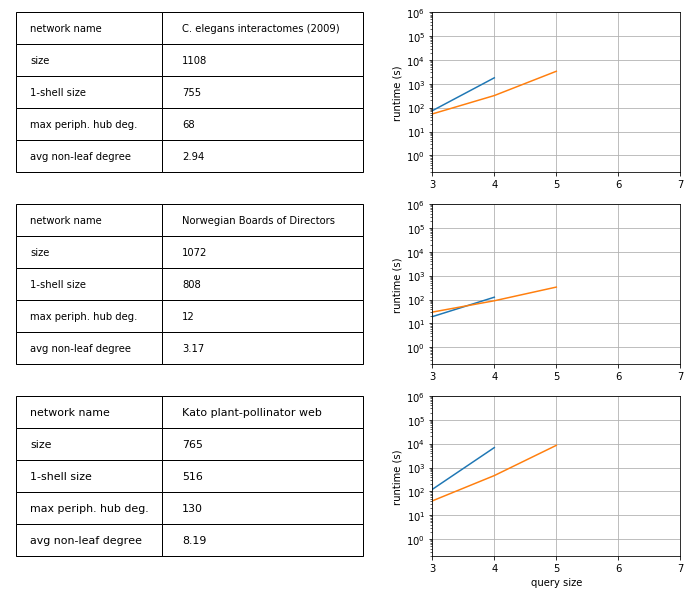

In [166]:
fig3, f3_axes = plt.subplots(ncols=2, nrows=3, constrained_layout=True)

for networkKey, networkIndex in enumerate(indices_lsample):
    ax2 = f3_axes[networkKey, 0]
    ax3 = f3_axes[networkKey, 1]
    
    edges = data_edgelists.iloc[networkIndex]
    networkGraph = nx.Graph()
    networkGraph.add_edges_from(edges)
    
    names = ['network name',
             'size',
             '1-shell size', 
             'max periph. hub deg.', 
             'avg non-leaf degree']
    
    values = [netStats[networkIndex]['title'][:30],
             len(networkGraph),
             netStats[networkIndex]['one_shell_size'],
             netStats[networkIndex]['max_peripheral_hub_degree'],
             round(netStats[networkIndex]['avg_one_shell_degree'], 2)]

    dat = [(names[i], values[i]) for i in range(len(names))]

    the_table = ax2.table(cellText=dat, cellLoc='left', loc=5, colWidths=[0.59, 0.81])
    table_props = the_table.properties()
    table_cells = table_props['child_artists']
    
    for cell in table_cells:
        cell.set_height(0.2)
        cell.set_text_props(fontsize=11)
        
        
    ax2.axis('tight')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['bottom'].set_visible(False)
    ax2.spines['left'].set_visible(False)
    ax2.set_xticks([])
    ax2.set_yticks([])
    
    ax3.plot([i for i in range(3, 6)], [runtimes_lsample[networkIndex][querySize]['total_fnr'] for querySize in range(3, 6)])
    ax3.plot([i for i in range(3, 6)], [runtimes_lsample[networkIndex][querySize]['total_fns'] for querySize in range(3, 6)])
    ax3.set_yscale('log')
    ax3.set_xlim([3, 7])
    ax3.set_ylim([0.2, 1000000])
    ax3.grid(True)
    ax3.set_ylabel('runtime (s)')
    ax3.set_xticks([i for i in range(3, 8)])
    
    if (networkIndex == 117):
        ax3.set_xlabel('query size')

    
fig3.set_size_inches(12, 10)
plt.subplots_adjust(wspace = 0.7)

In [137]:
fig3.savefig("/Users/mbpr/Desktop/internships/CU Boulder Summer 2019/Motif discovery/motif-discovery/paper/manuscript/runtime_comparison_lsample.pdf", bbox_inches='tight')


### query statistics

In [ ]:
querySize = 5

inputFile = 'test_data/allgraphs' + str(querySize) + 'indexed.txt'
f = open(inputFile, 'r')
queryGraphsData = f.readlines()

for key, val in enumerate(queryGraphsData):
        
    spaceIndex = val.find(' ')
    queryKey = val[:spaceIndex]
    queryString = val[spaceIndex+1:].rstrip()
    queryGraph = parseStringToGraph(queryString)
    
    

### sample queries from network

In [ ]:
networkIndex = 324
networkGraph = nx.Graph()
edges = data_edgelists.iloc[networkIndex]
networkGraph.add_edges_from(edges)

sampleGraph = sampleSubgraph(networkGraph, 10)
nx.draw(sampleGraph, with_labels=True)

In [863]:
graphToString(sampleGraph)

'[[161,215], [163,215], [643,159], [229,215], [229,309], [229,1072], [333,215], [215,159], [382,159]]'

In [ ]:
queryString = '[[804,208], [326,208], [806,118], [395,118], [395,208], [208,541], [208,819], [208,820], [304,118]]'
queryGraph = parseStringToGraph(queryString)
nx.draw(queryGraph, with_labels=True)

### write sampled queries to file

In [795]:
# write text file of sampled query strings
data = []
querySize = 10

for i in range(10):
    sampleGraph = sampleSubgraph(networkGraph, querySize)
    sampleString = graphToString(sampleGraph)
    data.append(str(i) + ' ' + sampleString + '\n')
    
f = open('test_data/allgraphs' + str(querySize) + '_' + str(networkIndex) + 'indexed.txt', 'w')
f.writelines(data)

### test simplified permanent feature

In [664]:
import functions_subtrees_wcs as fns_wcs
import scipy.special as sp
importlib.reload(fns_wcs)

# treeT = fns_wcs.randomTree(15, seed)
# treeS = fns_wcs.randomTree(60, seed)

stringT = '[[0,1], [0,2], [0,3], [0,4], [0,5], [0,6], [0,7], [0,8], [1,9], [1,10], [1,11], [1,12], [1,13]]'
stringS = '[[0,1], [0,2], [0,3], [0,4], [0,5], [0,6], [0,7], [0,8], [0,9], [0,10], [0,11], [0,12], [0,13], [0,14], [0,15], [0,16], [1,17], [1,18], [1,19], [1,20], [1,21], [1,22], [1,23], [1,24], [1,25], [1,26]]'

treeT = parseStringToGraph(stringT)
treeS = parseStringToGraph(stringS)

start_time_fns_wc = time.time()
out_fns_wc = fns_wc.countMatchings(treeT, 0, treeS, 0)
delta_fns_wc = time.time() - start_time_fns_wc

start_time_fns_wcs = time.time()
out_fns_wcs = fns_wcs.countMatchings(treeT, 0, treeS, 0)
delta_fns_wcs = time.time() - start_time_fns_wcs

print('regular:')
print('count:', out_fns_wc, 'runtime:', delta_fns_wc)
print('simplified:')
print('count:', out_fns_wcs, 'runtime:', delta_fns_wcs)

regular:
count: 1621620.0 runtime: 29.62465500831604
simplified:
count: 1621620.0 runtime: 0.0011827945709228516


In [ ]:
nx.draw(treeT, with_labels=True)

In [ ]:
nx.draw(treeS, with_labels=True)

In [663]:
for seed in range(2000, 3000):
    treeT = fns_wcs.randomTree(15, seed)
    treeS = fns_wcs.randomTree(60, seed)

    out_fns_wc = fns_wc.countMatchings(treeT, 14, treeS, 59)
    out_fns_wcs = fns_wcs.countMatchings(treeT, 14, treeS, 59)

#     print('subtrees:', out_fns_wc, 'simplified:', out_fns_wcs)

    if(out_fns_wc != out_fns_wcs):
        print('error')

## debug

In [ ]:
q6_5 = '[[0,4], [1,4], [2,5], [3,5], [4,5]]'
q6_38 = '[[0,5], [1,2], [1,5], [2,5], [3,4], [3,5], [4,5]]'
q7_8 = '[[0,5], [1,5], [2,6], [3,6], [4,5], [4,6]]'

queryString = q6_38
queryGraph = parseStringToGraph(queryString)

# networkString = '[[0,4], [1,4], [2,5], [3,5], [4,5], [0,6], [1,6]]'
# networkGraph = parseStringToGraph(networkString)

networkIndex = 503
networkGraph = nx.Graph()
edges = data_edgelists.iloc[networkIndex]
networkGraph.add_edges_from(edges)
networkString = graphToString(networkGraph)

nx.draw(queryGraph, with_labels=True)


In [537]:
K = nx.Graph()
K.add_edges_from(queryGraph.edges())
aut = fnr_wc.findSubgraphInstances(queryGraph, K, False)
M = fnr_wc.symmetryConditions(aut)
M

{0: {1, 2, 3}, 2: {3}}

In [ ]:
nx.draw(networkGraph, with_labels=True)

In [550]:
importlib.reload(fnr_wc)
importlib.reload(fns_wc)

start_time_fns = time.time()
out_fns = fns_wc.findSubgraphInstances(queryString, networkString)
delta_fns = time.time() - start_time_fns

start_time_fnr = time.time()
out_fnr = fnr_wc.findSubgraphInstances(queryGraph, networkGraph)
delta_fnr = time.time() - start_time_fnr
 
print('regular:', out_fnr, 'runtime:', delta_fnr)
print('subtrees:', out_fns, 'runtime:', delta_fns)

regular: 4442 runtime: 113.84949493408203
subtrees: 4442 runtime: 70.28314304351807


# useful functions

In [4]:
def sampleSubgraph(networkGraph, sampleSize):
    node = np.random.choice(list(networkGraph.nodes()), 1)[0]
    selection = [node]
    neighborhood = set(networkGraph[node])
    size = 1
    
    while size < sampleSize:
        newNode = np.random.choice(list(neighborhood), 1)[0]
        selection.append(newNode)
        neighborhood = neighborhood.union(set(networkGraph[newNode])).difference(set(selection))
        size = size +1
        
    return networkGraph.subgraph(selection)

def plotNetwork(index, nodeSize=50, withLabels=False, figSize=10):
    edges = data_edgelists.iloc[index]

    Graph = nx.Graph()
    Graph.add_edges_from(edges)
    pos = nx.drawing.kamada_kawai_layout(Graph, scale=1)
    fig, ax = plt.subplots()
    fig.set_size_inches(figSize, figSize)
    nodes = nx.draw_networkx_nodes(Graph, pos=pos, node_size = nodeSize, ax = ax)
    edges = nx.draw_networkx_edges(Graph, pos=pos, ax = ax)
    
    if (withLabels):
        labels = nx.draw_networkx_labels(Graph, pos=pos)

    plt.show()

def parseStringToGraph(s):
    l = []
    
    if(s[len(s)-1] == ' '):
        s = s[:-1]
    
    if(s[0] == '[' and s[len(s)-1] == ']'):
        s = s[-(len(s)-1):-1]
        start = [key for key, val in enumerate(s) if val == '[']
        end = [key for key, val in enumerate(s) if val == ']']
        comma = [key for key, val in enumerate(s) if (val == ',' and not s[key-1] == ']')]
        
        for i in range(len(start)):
            left = [v for k, v in enumerate(s) if k in range(start[i]+1, comma[i])]
            right = [v for k, v in enumerate(s) if k in range(comma[i]+1, end[i])]
            
            left = int(''.join(left))
            right = int(''.join(right))
            l.append((left, right))
    
    H = nx.Graph()
    H.add_edges_from(l)
    
    return H

def graphToString(G):
    edges = list(G.edges())
    string = '['
    
    for edge in edges:
        to_add = '[' + str(edge[0]) + ',' + str(edge[1]) + '], '
        string += to_add
        
    string = string[:len(string)-2]
    string += ']'
    
    return string

# takes a graph G and "grows" a 1-shell from it until it reaches size size
def growOneShell(G, size, seed):
    K = nx.Graph()
    rnd.seed(seed)
    
    if (size < len(G)):
        print('size too small')
        return
    
    n = len(G)
    m = size - n
    
    weighedNodeList = []
    
    for n in G.nodes():
        mult = [n]*len(G[n])
        weighedNodeList = weighedNodeList + mult
    
    for newNode in range(n, size):
        adjacentNode = rnd.sample(weighedNodeList, 1)
        G.add_edge(newNode, adjacentNode[0])
        
        for n in G.nodes():
            mult = [n]*len(G[n])
            weighedNodeList = weighedNodeList + mult
        
    K.add_edges_from(G.edges())
    return K


def write_speed_results(outFile, delta_fnr, delta_fns, stringQuery, graphName):
    f = open(outFile, 'r')
    old_data = f.readlines()
    
    of = open(outFile, 'w')
    str_subtrees_time = str(delta_fns)
    str_regular_time = str(delta_fnr)
    
    data = old_data + ['query graph: ', stringQuery, ', network: ', graphName, ', subtrees: ', str_subtrees_time, ', regular: ', str_regular_time]

    of.writelines(data)
    
    
def edgeList_to_string(file):
    f = open(file, 'r')
    data = f.readlines()
    string = '['
    
    for index, line in enumerate(data):
        split = line.split()
        
#         print(split[0], split[1])
        
        to_add = '[' + split[0] + ',' + split[1] + '], '
        string += to_add
        
    string = string[:len(string)-2]
    string += ']'
    
    return string

# adds a label column to an edgelist file
def add_label(file):
    f = open(file, 'r')
    
    data = f.readlines()
    
    for index, line in enumerate(data):
        
        split = line.split()
        print(index, data[index], split)
        
        if (len(split) == 1):
            temp = data[index].rstrip() + ' ' + data[index]
            data[index] = temp
            
    f = open(file, 'w')
    f.writelines(data)
    